# RL-HIGH-VARIANCE-REINFORCE TREATMENT PIPELINE

In [ ]:
!pip install torch numpy matplotlib

##v4

Device: cuda
Config: 8 seeds × 600 eps × 9 arms  |  preference_drift=True

Seed 1/8
  T0: Untreated                  | H=+0.408 | Imp=0.50 Crd=0.88 Jmp=1.00 Rig=0.48 Dft=0.10 | Ret=    22.9 | D=0
  T1: Baseline (MPH)             | H=+0.474 | Imp=0.50 Crd=0.89 Jmp=1.00 Rig=0.14 Dft=0.10 | Ret=    31.1 | D=27
  T2: Entropy (AMP)              | H=+0.623 | Imp=0.12 Crd=0.76 Jmp=1.00 Rig=0.00 Dft=0.00 | Ret=    20.0 | D=35
  T3: Combined Stim              | H=+0.378 | Imp=0.65 Crd=0.50 Jmp=0.29 Rig=1.00 Dft=0.68 | Ret= -1264.4 | D=106
  T4: Actor-Critic               | H=+0.418 | Imp=0.30 Crd=0.76 Jmp=0.66 Rig=1.00 Dft=0.19 | Ret=    -1.7 | D=125
  T5: PPO Cocktail               | H=+0.201 | Imp=0.68 Crd=0.91 Jmp=1.00 Rig=1.00 Dft=0.41 | Ret=   -17.3 | D=145
  T6: RLOO                       | H=+0.446 | Imp=0.32 Crd=0.70 Jmp=1.00 Rig=0.57 Dft=0.18 | Ret=    36.2 | D=82
  T7: GRPO                       | H=+0.209 | Imp=0.68 Crd=0.84 Jmp=1.00 Rig=1.00 Dft=0.43 | Ret=  -250.2 | D=114
  T8: REI

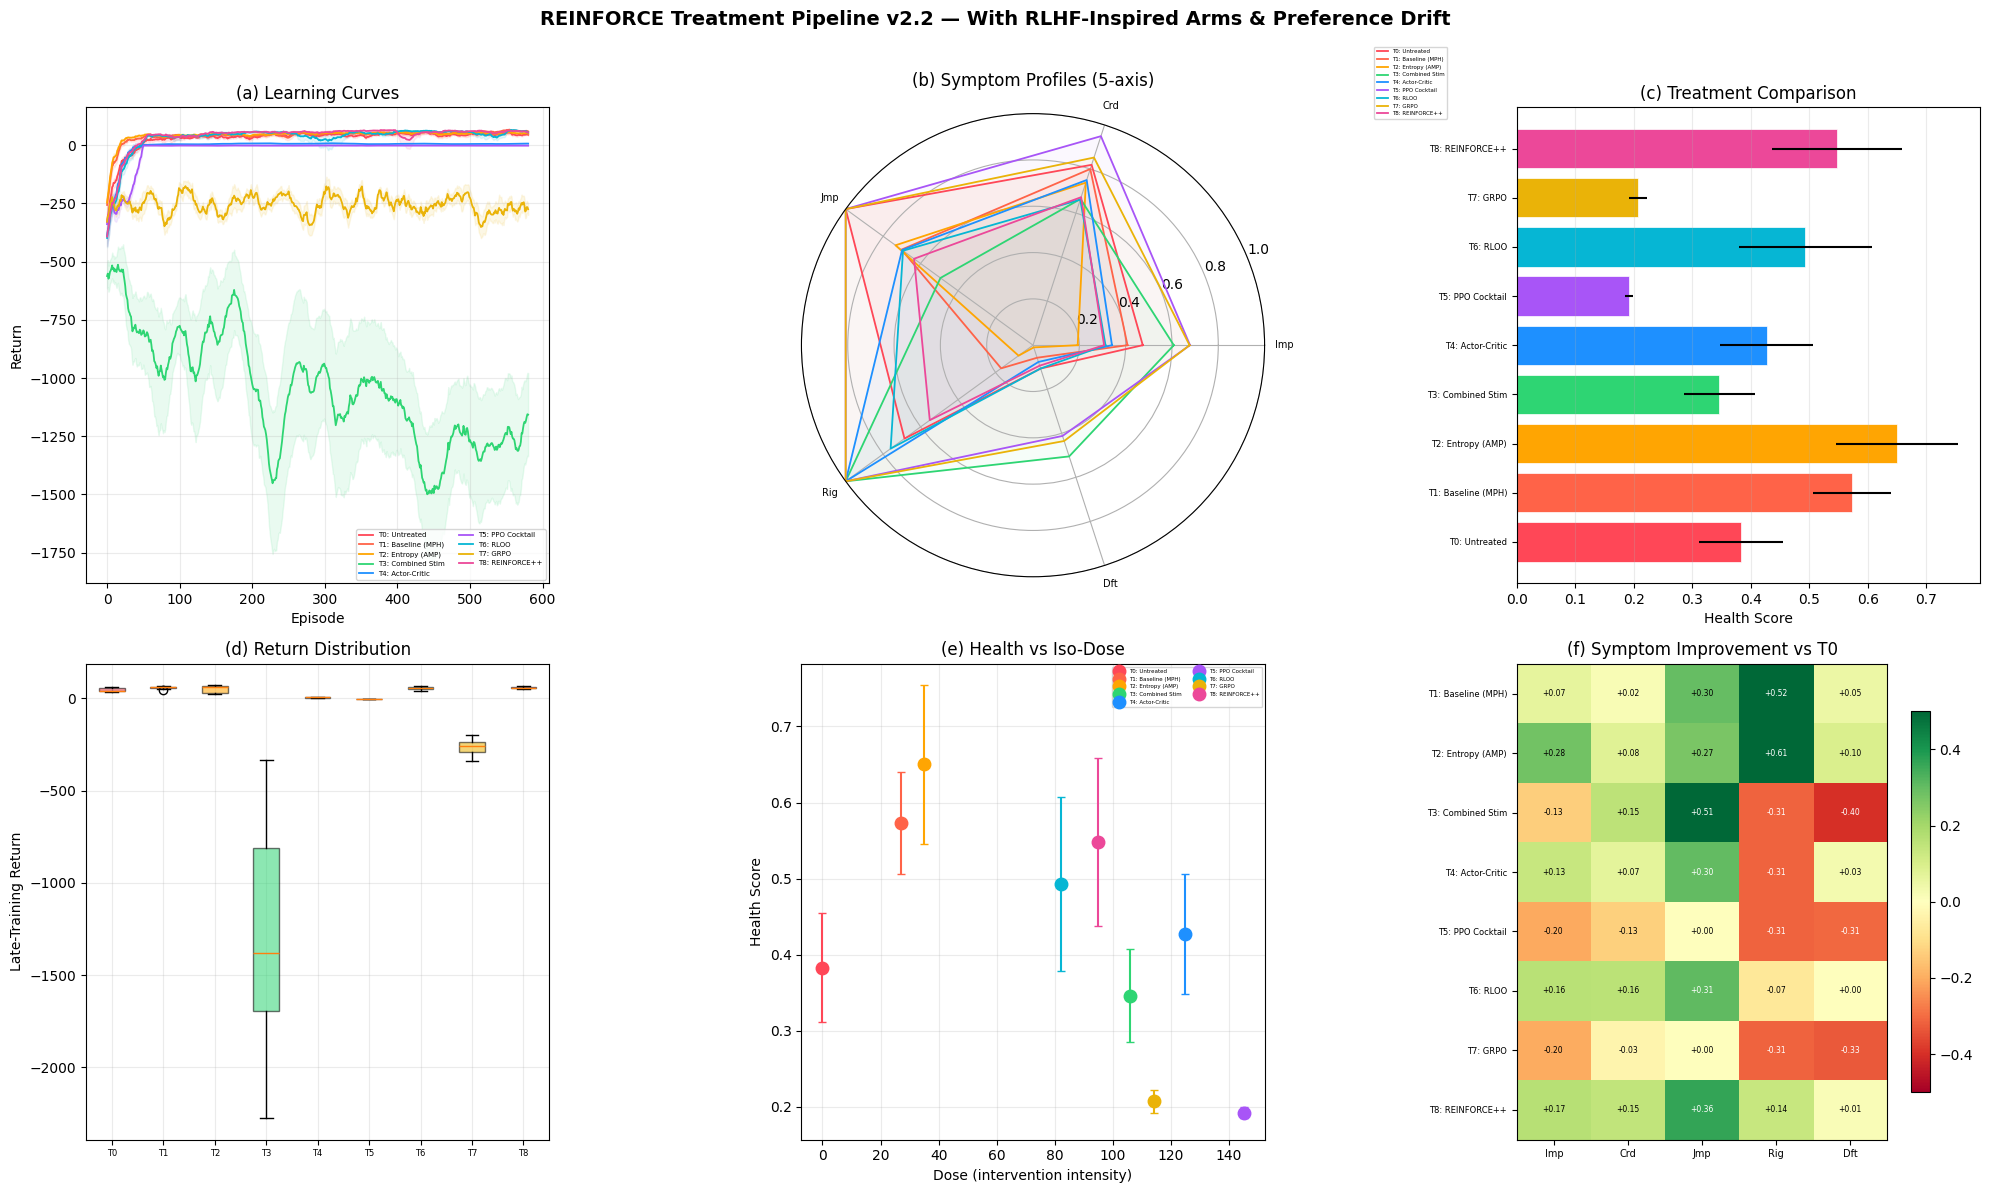

Plot saved → pipeline_v22_results.png


In [ ]:
"""
RL HIGH-VARIANCE REINFORCE — TREATMENT PIPELINE v2.2
=====================================================
Extends v2.1 with RLHF-Inspired Arms & Preference Drift

NEW IN v2.2 (§ markers continue from v2.1):
  §12 Preference drift     — post-reversal rewards shift toward budget-friendly
  §13 RLOO arm (T6)        — leave-one-out baseline, k=4, critic-free
  §14 GRPO arm (T7)        — group-relative advantages + clipping, critic-free
  §15 REINFORCE++ arm (T8) — global running advantage normalisation
  §16 S5 drift adaptation  — new symptom: policy tracking of drifting rewards
  §17 Unified baseline system — BASELINE_TYPE enum replaces USE_BASELINE flag
  §18 Per-step advantage    — LOO/GRPO baselines applied to step-level returns

v2.1 retained: §1-§11 (per-arm noise, random reversal, post-rev penalty,
               entropy anneal, T3 critic, batching, rwd-norm warmup,
               adaptive LR, iso-dose, JSON log, GPU)

Disease symptoms (5):
  S1 Impulsivity        — action entropy from noisy gradients
  S2 Credit Assignment   — can't attribute delayed rewards
  S3 Jumpy Learning      — unstable training curves
  S4 Reversal Rigidity   — slow adaptation to budget shock
  S5 Drift Adaptation    — failure to track drifting reward preferences

Treatment arms (9 — escalating / RLHF-inspired):
  T0 Untreated             — raw REINFORCE, high noise, high temp
  T1 Baseline (MPH)        — moving-average baseline
  T2 Entropy (AMP)         — entropy bonus + temp annealing
  T3 Combined Stim         — critic + ent + clip + adv norm
  T4 Actor-Critic          — T3 + batch-4 + rwd norm
  T5 PPO Cocktail          — T4 + PPO clipped surrogate
  T6 RLOO                  — leave-one-out baseline, k=4, critic-free   §13
  T7 GRPO                  — group-relative + PPO clip, critic-free     §14
  T8 REINFORCE++           — global running norm, robust to drift       §15

Authors: Ngo Cheung
Deps: torch >= 2.0, numpy, matplotlib
"""

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import json
import os
from collections import deque, OrderedDict
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
import matplotlib
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# §11 — GPU auto-detect
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 0. CONFIGURATION
# ============================================================
@dataclass
class Cfg:
    n_seeds:         int   = 8
    episodes:        int   = 600
    steps:           int   = 10
    n_actions:       int   = 4
    # --- MDP ---
    budget_init:     float = 1500.0
    budget_rev:      float = 400.0
    rev_step_lo:     int   = 3
    rev_step_hi:     int   = 8
    rev_step_mid:    int   = 5
    reward_noise:    float = 12.0
    cost_noise:      float = 5.0
    penalty:         float = 40.0
    post_rev_pen:    float = 3.0
    # §12 — preference drift
    preference_drift: bool  = True
    # --- Optimisation ---
    gamma:           float = 0.99
    gae_lam:         float = 0.95
    lr:              float = 3e-3
    lr_min:          float = 1e-5
    lr_decay_rate:   float = 0.995
    jumpy_thresh:    float = 0.8
    ent_coef:        float = 0.02
    ent_min:         float = 0.001
    val_coef:        float = 0.5
    grad_clip:       float = 0.5
    bl_window:       int   = 50
    # --- Temperature ---
    temp_init:       float = 1.0
    temp_min:        float = 0.3
    temp_decay:      float = 0.995
    # --- PPO ---
    ppo_clip:        float = 0.2
    ppo_epochs:      int   = 4
    # --- Reward norm ---
    rwd_norm_warmup: int   = 50

C = Cfg()


# ============================================================
# 1. MDP — Budget Planning + Randomised Reversal + Preference Drift
# ============================================================
class BudgetMDP:
    COSTS         = np.array([120.0, 60.0, 25.0,  0.0])
    REWARDS       = np.array([ 15.0, 10.0,  5.0,  1.0])
    DRIFT_REWARDS = np.array([  2.0,  5.0, 12.0,  8.0])  # §12 economy > luxury

    def __init__(self, rng: np.random.RandomState):
        self.rng = rng
        self.reset()

    def reset(self):
        self.day      = 0
        self.spent    = 0.0
        self.budget   = C.budget_init
        self.reversed = False
        self.rev_step = self.rng.randint(C.rev_step_lo, C.rev_step_hi)
        return self._s()

    def _s(self):
        return np.array([
            self.day / C.steps,
            self.spent / C.budget_init,
            self.budget / C.budget_init,
        ], dtype=np.float32)

    def step(self, a: int, reward_noise: float = None):
        noise = reward_noise if reward_noise is not None else C.reward_noise
        cost  = self.COSTS[a] + self.rng.normal(0, C.cost_noise)
        self.spent += max(0.0, cost)
        self.day   += 1

        # --- reversal ---
        if self.day == self.rev_step and not self.reversed:
            self.budget   = C.budget_rev
            self.reversed = True

        # --- reward with drift §12 ---
        if self.reversed and C.preference_drift:
            remaining = max(1, C.steps - self.rev_step)
            drift_t   = (self.day - self.rev_step) / remaining
            alpha     = min(1.0, max(0.0, drift_t))
            base_r    = self.REWARDS[a] * (1.0 - alpha) + self.DRIFT_REWARDS[a] * alpha
        else:
            base_r = self.REWARDS[a]
        r = base_r + self.rng.normal(0, noise)

        # reversal shock
        if self.day == self.rev_step:
            r -= 5.0

        # §3 post-reversal cost penalty for expensive actions
        if self.reversed and a <= 1:
            r -= C.post_rev_pen

        done = self.day >= C.steps
        if done:
            r -= C.penalty * max(0.0, self.spent - self.budget) / C.steps
        return self._s(), r, done


# ============================================================
# 2. NETWORKS (LayerNorm + orthogonal init)
# ============================================================
def ortho_init(module, gain=1.0):
    for m in module.modules():
        if isinstance(m, nn.Linear):
            nn.init.orthogonal_(m.weight, gain=gain)
            nn.init.zeros_(m.bias)
    return module


class PolicyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64), nn.LayerNorm(64), nn.Tanh(),
            nn.Linear(64, 32), nn.LayerNorm(32), nn.Tanh(),
            nn.Linear(32, C.n_actions),
        )
        ortho_init(self, gain=0.01)

    def forward(self, x, temp=1.0):
        return torch.softmax(self.net(x) / temp, dim=-1)


class ValueNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64), nn.LayerNorm(64), nn.Tanh(),
            nn.Linear(64, 32), nn.Tanh(),
            nn.Linear(32, 1),
        )
        ortho_init(self, gain=1.0)

    def forward(self, x):
        return self.net(x).squeeze(-1)


# ============================================================
# 3. RUNNING STATS
# ============================================================
class RunningStats:
    def __init__(self, win: int = 100):
        self.d = deque(maxlen=win)

    def push(self, x: float):
        self.d.append(x)

    @property
    def mean(self) -> float:
        return float(np.mean(self.d)) if self.d else 0.0

    @property
    def std(self) -> float:
        return max(float(np.std(self.d)), 1e-8) if len(self.d) > 1 else 1.0

    def norm(self, x: float) -> float:
        return (x - self.mean) / self.std


# ============================================================
# 4. TREATMENT BASE + 9 ARMS
# ============================================================
class Treatment:
    """T0: Untreated — raw REINFORCE with amplified noise."""
    NAME = "T0: Untreated"

    # --- feature flags ---
    BASELINE_TYPE  = 'none'        # §17 'none','moving_avg','leave_one_out','group_relative','global_running'
    USE_ENTROPY    = False
    USE_GRAD_CLIP  = False
    USE_ADV_NORM   = False
    USE_CRITIC     = False
    USE_RWD_NORM   = False
    USE_PPO        = False
    TEMP_ANNEAL    = False
    USE_LR_DECAY   = False

    # --- per-arm tuning ---
    TEMP_MULT      = 1.5
    REWARD_NOISE   = 20.0
    ENT_COEF_INIT  = 0.0
    ENT_DECAY      = 1.0
    BATCH_SIZE     = 1

    def __init__(self):
        self.policy = PolicyNet().to(DEVICE)
        self.p_opt  = optim.Adam(self.policy.parameters(), lr=C.lr)
        self.vnet   = ValueNet().to(DEVICE) if self.USE_CRITIC else None
        self.v_opt  = (optim.Adam(self.vnet.parameters(), lr=C.lr)
                       if self.vnet else None)
        self.bl              = RunningStats(C.bl_window)
        self.rwd_st          = RunningStats(200)
        self._global_ret_st  = RunningStats(500)       # §15 for REINFORCE++
        self.ep              = 0
        self.ent_coef        = self.ENT_COEF_INIT

        self._batch_bufs: List[list] = []
        self._batch_ep_n = 0
        self._recent_rets = deque(maxlen=50)

    # ---- temperature ----
    def _temp(self) -> float:
        t = C.temp_init * self.TEMP_MULT
        if self.TEMP_ANNEAL:
            t = max(C.temp_min, t * (C.temp_decay ** self.ep))
        return t

    def _decay_entropy(self):
        if self.USE_ENTROPY and self.ENT_DECAY < 1.0:
            self.ent_coef = max(C.ent_min, self.ent_coef * self.ENT_DECAY)

    def _maybe_decay_lr(self):
        if not self.USE_LR_DECAY or len(self._recent_rets) < 50:
            return
        tail = list(self._recent_rets)
        mu   = np.mean(tail)
        cv   = np.std(tail) / (abs(mu) + 1e-5)
        if cv > C.jumpy_thresh:
            for pg in self.p_opt.param_groups:
                pg['lr'] = max(pg['lr'] * C.lr_decay_rate, C.lr_min)
            if self.v_opt:
                for pg in self.v_opt.param_groups:
                    pg['lr'] = max(pg['lr'] * C.lr_decay_rate, C.lr_min)

    # ---- discounted returns ----
    @staticmethod
    def _returns(rewards: List[float]) -> List[float]:
        R, out = 0.0, []
        for r in reversed(rewards):
            R = r + C.gamma * R
            out.insert(0, R)
        return out

    # ---- GAE ----
    def _gae(self, rewards, values):
        T    = len(rewards)
        advs = [0.0] * T
        gae  = 0.0
        for t in reversed(range(T)):
            nv    = values[t + 1] if t + 1 < len(values) else 0.0
            delta = rewards[t] + C.gamma * nv - values[t]
            gae   = delta + C.gamma * C.gae_lam * gae
            advs[t] = gae
        rets = [a + v for a, v in zip(advs, values[:T])]
        return advs, rets

    # §9 — iso-dose score
    def get_dose(self) -> float:
        d = max(0.0, (20.0 - self.REWARD_NOISE)) * 1.5
        if self.BASELINE_TYPE == 'moving_avg':      d += 15
        if self.BASELINE_TYPE == 'leave_one_out':    d += 20
        if self.BASELINE_TYPE == 'group_relative':   d += 22
        if self.BASELINE_TYPE == 'global_running':   d += 18
        if self.USE_ENTROPY:    d += 15
        if self.USE_GRAD_CLIP:  d += 10
        if self.USE_ADV_NORM:   d += 10
        if self.USE_CRITIC:     d += 25
        if self.USE_RWD_NORM:   d += 8
        if self.USE_PPO:        d += 20
        if self.TEMP_ANNEAL:    d += 8
        if self.USE_LR_DECAY:   d += 5
        if self.BATCH_SIZE > 1: d += 8
        return d

    # §17 — compute per-episode advantages from baseline type
    def _compute_advantages(self, ep_idx: int,
                            rets: List[float]) -> List[float]:
        bt = self.BASELINE_TYPE
        if bt == 'none':
            return list(rets)

        elif bt == 'moving_avg':
            base = self.bl.mean
            return [r - base for r in rets]

        elif bt == 'leave_one_out':                           # §13
            ep_returns = [sum(b['r'] for b in ep)
                          for ep in self._batch_bufs]
            k = len(ep_returns)
            if k > 1:
                total    = sum(ep_returns)
                loo_base = (total - ep_returns[ep_idx]) / (k - 1)
            else:
                loo_base = 0.0
            return [r - loo_base for r in rets]

        elif bt == 'group_relative':                          # §14
            ep_returns = [sum(b['r'] for b in ep)
                          for ep in self._batch_bufs]
            mu  = np.mean(ep_returns)
            std = max(np.std(ep_returns), 1e-8)
            return [(r - mu) / std for r in rets]

        elif bt == 'global_running':                          # §15
            return [self._global_ret_st.norm(r) for r in rets]

        return list(rets)

    # ======== MAIN ENTRY ========
    def train_episode(self, env: BudgetMDP):
        self.ep += 1
        state   = env.reset()
        ep_buf  = []

        for _ in range(C.steps):
            st    = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            probs = self.policy(st, temp=self._temp())
            dist  = torch.distributions.Categorical(probs)
            a     = dist.sample()
            lp    = dist.log_prob(a)
            ent   = dist.entropy()
            val   = self.vnet(st).item() if self.vnet else 0.0

            ns, r, done = env.step(a.item(), reward_noise=self.REWARD_NOISE)

            if self.USE_RWD_NORM:
                self.rwd_st.push(r)
                if self.ep > C.rwd_norm_warmup:
                    r = r / (self.rwd_st.std + 1e-8)

            ep_buf.append(dict(s=state.copy(), a=a.item(), r=r,
                               lp=lp, ent=ent, v=val))
            state = ns
            if done:
                break

        rewards = [b['r'] for b in ep_buf]
        raw_ret = sum(rewards)

        # store episode in batch buffer (advantages computed in batch update)
        self._batch_bufs.append(ep_buf)
        self._batch_ep_n += 1

        if self._batch_ep_n >= self.BATCH_SIZE:
            self._do_batch_update()

        # bookkeeping
        if self.BASELINE_TYPE == 'moving_avg':
            self.bl.push(raw_ret)
        self._global_ret_st.push(raw_ret)
        self._decay_entropy()
        self._recent_rets.append(raw_ret)
        self._maybe_decay_lr()

        rev_s   = env.rev_step
        pre     = float(np.mean(rewards[:rev_s - 1])) if rev_s > 1 else 0.0
        post    = float(np.mean(rewards[rev_s:])) if len(rewards) > rev_s else 0.0
        actions = [b['a'] for b in ep_buf]
        return raw_ret, actions, pre, post

    def flush_batch(self):
        if self._batch_bufs:
            self._do_batch_update()

    # ======== BATCH UPDATE ========
    def _do_batch_update(self):
        # Step 1 — compute advantages per episode
        for i, ep_buf in enumerate(self._batch_bufs):
            rewards = [b['r'] for b in ep_buf]
            if self.USE_CRITIC and self.vnet:
                vals       = [b['v'] for b in ep_buf]
                advs, rets = self._gae(rewards, vals)
            else:
                rets = self._returns(rewards)
                advs = self._compute_advantages(i, rets)
            for j, b in enumerate(ep_buf):
                b['adv'] = advs[j]
                b['ret'] = rets[j]

        # Step 2 — flatten
        flat = [b for ep in self._batch_bufs for b in ep]

        # Step 3 — advantage normalisation
        if self.USE_ADV_NORM and len(flat) > 1:
            aa = np.array([b['adv'] for b in flat])
            aa = (aa - aa.mean()) / (aa.std() + 1e-8)
            for k, b in enumerate(flat):
                b['adv'] = float(aa[k])

        # Step 4 — policy update
        if self.USE_PPO:
            self._ppo_update(flat)
        else:
            self._pg_update(flat)

        # Step 5 — critic update
        if self.vnet:
            self._critic_update(flat)

        self._batch_bufs = []
        self._batch_ep_n = 0

    # ---- vanilla PG ----
    def _pg_update(self, buf: list):
        loss = torch.tensor(0.0, device=DEVICE)
        for b in buf:
            loss = loss - b['lp'] * b['adv']
            if self.USE_ENTROPY:
                loss = loss - self.ent_coef * b['ent']
        loss = loss / max(1, len(self._batch_bufs) if self._batch_bufs else self.BATCH_SIZE)
        self.p_opt.zero_grad()
        loss.backward()
        if self.USE_GRAD_CLIP:
            nn.utils.clip_grad_norm_(self.policy.parameters(), C.grad_clip)
        self.p_opt.step()

    # ---- PPO clipped ----
    def _ppo_update(self, buf: list):
        states  = torch.FloatTensor(np.array([b['s'] for b in buf])).to(DEVICE)
        actions = torch.LongTensor([b['a'] for b in buf]).to(DEVICE)
        old_lps = torch.stack([b['lp'] for b in buf]).detach()
        adv_t   = torch.FloatTensor([b['adv'] for b in buf]).to(DEVICE)

        for _ in range(C.ppo_epochs):
            probs   = self.policy(states, temp=self._temp())
            dist    = torch.distributions.Categorical(probs)
            new_lps = dist.log_prob(actions)
            ent     = dist.entropy()
            ratio   = torch.exp(new_lps - old_lps)
            clip_r  = torch.clamp(ratio, 1 - C.ppo_clip, 1 + C.ppo_clip)
            loss    = -torch.min(ratio * adv_t, clip_r * adv_t).mean()
            if self.USE_ENTROPY:
                loss = loss - self.ent_coef * ent.mean()
            self.p_opt.zero_grad()
            loss.backward()
            if self.USE_GRAD_CLIP:
                nn.utils.clip_grad_norm_(self.policy.parameters(), C.grad_clip)
            self.p_opt.step()

    # ---- critic MSE ----
    def _critic_update(self, buf: list):
        states = torch.FloatTensor(np.array([b['s'] for b in buf])).to(DEVICE)
        tgt    = torch.FloatTensor([b['ret'] for b in buf]).to(DEVICE)
        vals   = self.vnet(states)
        loss   = C.val_coef * ((tgt - vals) ** 2).mean()
        self.v_opt.zero_grad()
        loss.backward()
        if self.USE_GRAD_CLIP:
            nn.utils.clip_grad_norm_(self.vnet.parameters(), C.grad_clip)
        self.v_opt.step()


# ----------------------------------------------------------------
# CONCRETE TREATMENT ARMS (T0-T5 from v2.1, T6-T8 new)
# ----------------------------------------------------------------
class T1_Baseline(Treatment):
    NAME           = "T1: Baseline (MPH)"
    BASELINE_TYPE  = 'moving_avg'
    TEMP_MULT      = 1.0
    REWARD_NOISE   = 12.0

class T2_Entropy(Treatment):
    NAME           = "T2: Entropy (AMP)"
    USE_ENTROPY    = True
    TEMP_ANNEAL    = True
    TEMP_MULT      = 1.0
    REWARD_NOISE   = 12.0
    ENT_COEF_INIT  = 0.05
    ENT_DECAY      = 0.995

class T3_Combined(Treatment):
    NAME           = "T3: Combined Stim"
    BASELINE_TYPE  = 'moving_avg'
    USE_ENTROPY    = True
    USE_GRAD_CLIP  = True
    USE_ADV_NORM   = True
    USE_CRITIC     = True
    TEMP_ANNEAL    = True
    TEMP_MULT      = 1.0
    USE_LR_DECAY   = True
    REWARD_NOISE   = 8.0
    ENT_COEF_INIT  = 0.05
    ENT_DECAY      = 0.995

class T4_ActorCritic(Treatment):
    NAME           = "T4: Actor-Critic"
    BASELINE_TYPE  = 'moving_avg'
    USE_ENTROPY    = True
    USE_GRAD_CLIP  = True
    USE_ADV_NORM   = True
    USE_CRITIC     = True
    USE_RWD_NORM   = True
    TEMP_ANNEAL    = True
    TEMP_MULT      = 1.0
    USE_LR_DECAY   = True
    REWARD_NOISE   = 6.0
    ENT_COEF_INIT  = 0.03
    ENT_DECAY      = 0.997
    BATCH_SIZE     = 4

class T5_PPO(Treatment):
    NAME           = "T5: PPO Cocktail"
    BASELINE_TYPE  = 'moving_avg'
    USE_ENTROPY    = True
    USE_GRAD_CLIP  = True
    USE_ADV_NORM   = True
    USE_CRITIC     = True
    USE_RWD_NORM   = True
    USE_PPO        = True
    TEMP_ANNEAL    = True
    TEMP_MULT      = 1.0
    USE_LR_DECAY   = True
    REWARD_NOISE   = 6.0
    ENT_COEF_INIT  = 0.03
    ENT_DECAY      = 0.997
    BATCH_SIZE     = 4

# ---------- §13 RLOO ----------
class T6_RLOO(Treatment):
    """Leave-One-Out baseline, k=4 rollouts, critic-free.
    Inspired by Ahmadian et al. 2024 — 2-3x faster than PPO, 10-32% higher
    win-rates.  LOO baseline from concurrent rollouts removes the need for
    a learned critic while providing effective variance reduction."""
    NAME           = "T6: RLOO"
    BASELINE_TYPE  = 'leave_one_out'
    USE_ENTROPY    = True
    USE_GRAD_CLIP  = True
    TEMP_ANNEAL    = True
    TEMP_MULT      = 1.0
    REWARD_NOISE   = 6.0
    ENT_COEF_INIT  = 0.03
    ENT_DECAY      = 0.997
    BATCH_SIZE     = 4

# ---------- §14 GRPO ----------
class T7_GRPO(Treatment):
    """Group Relative Policy Optimisation — group-normalised advantages with
    PPO clipping, no critic.  Mirrors DeepSeek-R1 training: excels in
    long chain-of-thought reasoning via group averaging."""
    NAME           = "T7: GRPO"
    BASELINE_TYPE  = 'group_relative'
    USE_ENTROPY    = True
    USE_GRAD_CLIP  = True
    USE_ADV_NORM   = True
    USE_PPO        = True
    TEMP_ANNEAL    = True
    TEMP_MULT      = 1.0
    REWARD_NOISE   = 6.0
    ENT_COEF_INIT  = 0.03
    ENT_DECAY      = 0.997
    BATCH_SIZE     = 4

# ---------- §15 REINFORCE++ ----------
class T8_REINFORCE_PP(Treatment):
    """REINFORCE++ — global running advantage normalisation.  Most robust to
    prompt/reward distribution shifts, outperforms RLOO/GRPO in
    non-stationary settings by +5-10% on agentic tasks."""
    NAME           = "T8: REINFORCE++"
    BASELINE_TYPE  = 'global_running'
    USE_ENTROPY    = True
    USE_GRAD_CLIP  = True
    USE_ADV_NORM   = True
    TEMP_ANNEAL    = True
    TEMP_MULT      = 1.0
    USE_LR_DECAY   = True
    REWARD_NOISE   = 6.0
    ENT_COEF_INIT  = 0.03
    ENT_DECAY      = 0.997
    BATCH_SIZE     = 4

ARMS = [Treatment, T1_Baseline, T2_Entropy, T3_Combined,
        T4_ActorCritic, T5_PPO, T6_RLOO, T7_GRPO, T8_REINFORCE_PP]


# ============================================================
# 5. SYMPTOM SCORING (5 symptoms)
# ============================================================
def score_symptoms(rets: List[float], acts: List[List[int]],
                   pre_list: List[float],
                   post_list: List[float]) -> Dict[str, float]:
    sym  = {}
    SPLIT = C.rev_step_mid

    # S1 — Impulsivity
    stds    = [np.std(a) for a in acts if len(a) > 1]
    max_std = (C.n_actions - 1) / 2.0
    sym['impulsivity'] = round(
        np.mean(stds) / max_std if stds else 1.0, 3)

    # S2 — Credit assignment
    early = [np.std(a[:SPLIT]) if len(a) >= SPLIT else 0.0 for a in acts]
    if len(early) > 1 and np.std(early) > 1e-5 and np.std(rets) > 1e-5:
        c = np.corrcoef(early, rets)[0, 1]
        sym['credit_assign'] = round(1.0 - abs(0.0 if np.isnan(c) else c), 3)
    else:
        sym['credit_assign'] = 1.0

    # S3 — Jumpy learning
    q    = max(1, len(rets) // 4)
    tail = rets[-q:]
    mu   = np.mean(tail) if tail else 1e-5
    sym['jumpy_learning'] = round(
        min(1.0, np.std(tail) / (abs(mu) + 1e-5)) if tail else 1.0, 3)

    # S4 — Reversal rigidity
    pre_m  = np.mean(pre_list)  if pre_list  else 0.0
    post_m = np.mean(post_list) if post_list else 0.0
    rig    = max(0.0, (pre_m - post_m) / (abs(pre_m) + 1e-5))
    sym['reversal_rigid'] = round(min(1.0, rig), 3)

    # S5 — Drift adaptation  §16
    # In late episodes, post-reversal actions should favour budget-friendly
    # choices (a >= 2: economy or skip).  Higher symptom = worse adaptation.
    q2           = max(1, len(acts) // 4)
    late_acts    = acts[-q2:]
    post_rev_all = []
    for ep_a in late_acts:
        post_rev_all.extend(ep_a[SPLIT:])
    if post_rev_all:
        frac_good = sum(1 for a in post_rev_all if a >= 2) / len(post_rev_all)
        sym['drift_adapt'] = round(1.0 - frac_good, 3)
    else:
        sym['drift_adapt'] = 1.0

    return sym


def health(sym: Dict[str, float]) -> float:
    return round(1.0 - np.mean(list(sym.values())), 3)


# ============================================================
# 6. MAIN PIPELINE
# ============================================================
def run_pipeline(cfg: Cfg = C):
    print(f"Device: {DEVICE}")
    print(f"Config: {cfg.n_seeds} seeds × {cfg.episodes} eps × "
          f"{len(ARMS)} arms  |  preference_drift={cfg.preference_drift}\n")

    results    = OrderedDict()
    curve_data = OrderedDict()

    for seed in range(cfg.n_seeds):
        print(f"Seed {seed + 1}/{cfg.n_seeds}")
        for ArmCls in ARMS:
            torch.manual_seed(seed)
            np.random.seed(seed)

            tx  = ArmCls()
            env = BudgetMDP(np.random.RandomState(seed))

            ep_rets, ep_acts, pres, posts = [], [], [], []
            for ep in range(cfg.episodes):
                ret, acts, pre, post = tx.train_episode(env)
                ep_rets.append(ret)
                ep_acts.append(acts)
                pres.append(pre)
                posts.append(post)
            tx.flush_batch()

            sym  = score_symptoms(ep_rets, ep_acts, pres, posts)
            h    = health(sym)
            dose = tx.get_dose()

            rec = dict(seed=seed, treatment=tx.NAME, symptoms=sym,
                       health=h, mean_ret=round(float(np.mean(ep_rets)), 2),
                       dose=round(dose, 1))
            results.setdefault(tx.NAME, []).append(rec)
            curve_data.setdefault(tx.NAME, []).append(ep_rets)

            sn = sym
            print(f"  {tx.NAME:30s} | H={h:+.3f} | "
                  f"Imp={sn['impulsivity']:.2f} Crd={sn['credit_assign']:.2f} "
                  f"Jmp={sn['jumpy_learning']:.2f} Rig={sn['reversal_rigid']:.2f} "
                  f"Dft={sn['drift_adapt']:.2f} | "
                  f"Ret={rec['mean_ret']:8.1f} | D={dose:.0f}")

    # ======== AGGREGATE ========
    print("\n" + "=" * 105)
    print(f"{'Treatment':30s} {'Health':>10s} {'Imp':>6s} {'Crd':>6s} "
          f"{'Jmp':>6s} {'Rig':>6s} {'Dft':>6s} {'Return':>9s} "
          f"{'Dose':>6s} {'NrmD':>6s}")
    print("-" * 105)

    agg   = OrderedDict()
    doses = {}
    for name, recs in results.items():
        hs  = [r['health'] for r in recs]
        ss  = {k: float(np.mean([r['symptoms'][k] for r in recs]))
               for k in recs[0]['symptoms']}
        mr  = float(np.mean([r['mean_ret'] for r in recs]))
        ds  = float(np.mean([r['dose'] for r in recs]))
        doses[name] = ds
        agg[name] = dict(
            health_mean=round(np.mean(hs), 3),
            health_std=round(np.std(hs), 3),
            symptoms={k: round(v, 3) for k, v in ss.items()},
            mean_ret=round(mr, 1),
            dose=round(ds, 1),
        )

    max_dose = max(doses.values()) if doses else 1.0
    for name in agg:
        agg[name]['dose_norm'] = round(agg[name]['dose'] / max_dose, 3)

    for name, a in agg.items():
        ss = a['symptoms']
        print(f"{name:30s} {a['health_mean']:+.3f}±{a['health_std']:.3f}"
              f"  {ss['impulsivity']:.3f} {ss['credit_assign']:.3f}"
              f" {ss['jumpy_learning']:.3f} {ss['reversal_rigid']:.3f}"
              f" {ss['drift_adapt']:.3f}"
              f"  {a['mean_ret']:9.1f} {a['dose']:6.0f} {a['dose_norm']:6.3f}")

    # §10 — JSON
    log = dict(version="2.2", config=cfg.__dict__, aggregate=agg,
               per_seed={n: r for n, r in results.items()})
    json_path = "results_v22.json"
    with open(json_path, "w") as f:
        json.dump(log, f, indent=2, default=str)
    print(f"\nJSON saved → {json_path}")

    plot_results(curve_data, agg, cfg)
    return results, agg


# ============================================================
# 7. PLOTTING
# ============================================================
COLORS = ['#ff4757', '#ff6348', '#ffa502', '#2ed573', '#1e90ff',
          '#a855f7', '#06b6d4', '#eab308', '#ec4899']

SKEYS  = ['impulsivity', 'credit_assign', 'jumpy_learning',
          'reversal_rigid', 'drift_adapt']
SLABS  = ['Imp', 'Crd', 'Jmp', 'Rig', 'Dft']


def smooth(x, w=20):
    return np.convolve(x, np.ones(w) / w, mode='valid')


def plot_results(curves, agg, cfg):
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle("REINFORCE Treatment Pipeline v2.2 — "
                 "With RLHF-Inspired Arms & Preference Drift",
                 fontsize=14, fontweight='bold', y=0.99)
    names = list(agg.keys())
    n_arms = len(names)

    # (a) Learning curves -----------------------------------------------
    ax1 = fig.add_subplot(2, 3, 1)
    for i, name in enumerate(names):
        arr     = [smooth(c, 20) for c in curves[name]]
        min_len = min(len(a) for a in arr)
        mat     = np.array([a[:min_len] for a in arr])
        mu      = mat.mean(0)
        se      = mat.std(0) / np.sqrt(mat.shape[0])
        x       = np.arange(len(mu))
        ax1.plot(x, mu, color=COLORS[i], label=name, linewidth=1.3)
        ax1.fill_between(x, mu - se, mu + se, color=COLORS[i], alpha=0.10)
    ax1.set_xlabel("Episode"); ax1.set_ylabel("Return")
    ax1.set_title("(a) Learning Curves")
    ax1.legend(fontsize=5, loc='lower right', ncol=2); ax1.grid(alpha=0.25)

    # (b) Radar — 5 symptom axes ----------------------------------------
    ax2    = fig.add_subplot(2, 3, 2, polar=True)
    angles = np.linspace(0, 2 * np.pi, len(SKEYS), endpoint=False).tolist()
    angles += angles[:1]
    for i, name in enumerate(names):
        vals  = [agg[name]['symptoms'][k] for k in SKEYS] + \
                [agg[name]['symptoms'][SKEYS[0]]]
        ax2.plot(angles, vals, color=COLORS[i], linewidth=1.3, label=name)
        ax2.fill(angles, vals, color=COLORS[i], alpha=0.04)
    ax2.set_xticks(angles[:-1]); ax2.set_xticklabels(SLABS, fontsize=7)
    ax2.set_ylim(0, 1)
    ax2.set_title("(b) Symptom Profiles (5-axis)", pad=20)
    ax2.legend(fontsize=4, loc='upper right', bbox_to_anchor=(1.4, 1.15))

    # (c) Health bars ----------------------------------------------------
    ax3 = fig.add_subplot(2, 3, 3)
    hs   = [agg[n]['health_mean'] for n in names]
    errs = [agg[n]['health_std']  for n in names]
    ax3.barh(range(n_arms), hs, xerr=errs,
             color=[COLORS[i] for i in range(n_arms)],
             edgecolor='white', linewidth=0.5)
    ax3.set_yticks(range(n_arms))
    ax3.set_yticklabels(names, fontsize=6)
    ax3.set_xlabel("Health Score"); ax3.set_title("(c) Treatment Comparison")
    ax3.axvline(0, color='gray', ls='--', alpha=0.4); ax3.grid(axis='x', alpha=0.25)

    # (d) Return distributions -------------------------------------------
    ax4  = fig.add_subplot(2, 3, 4)
    data = []
    for name in names:
        q = max(1, cfg.episodes // 4)
        data.append([np.mean(c[-q:]) for c in curves[name]])
    bp = ax4.boxplot(data, vert=True, patch_artist=True,
                     labels=[n.split(':')[0] for n in names])
    for patch, c in zip(bp['boxes'], COLORS):
        patch.set_facecolor(c); patch.set_alpha(0.55)
    ax4.set_ylabel("Late-Training Return")
    ax4.set_title("(d) Return Distribution")
    ax4.tick_params(axis='x', labelsize=6); ax4.grid(alpha=0.25)

    # (e) Iso-dose scatter -----------------------------------------------
    ax5 = fig.add_subplot(2, 3, 5)
    for i, name in enumerate(names):
        d = agg[name]['dose']
        h = agg[name]['health_mean']
        e = agg[name]['health_std']
        ax5.errorbar(d, h, yerr=e, fmt='o', color=COLORS[i],
                     markersize=9, capsize=3, label=name)
    ax5.set_xlabel("Dose (intervention intensity)")
    ax5.set_ylabel("Health Score")
    ax5.set_title("(e) Health vs Iso-Dose")
    ax5.legend(fontsize=4, ncol=2); ax5.grid(alpha=0.25)

    # (f) Heatmap — improvement over T0 ----------------------------------
    ax6     = fig.add_subplot(2, 3, 6)
    t0_sym  = agg[names[0]]['symptoms']
    imp_mat = []
    for name in names[1:]:
        row = [t0_sym[k] - agg[name]['symptoms'][k] for k in SKEYS]
        imp_mat.append(row)
    imp_mat = np.array(imp_mat)
    im = ax6.imshow(imp_mat, cmap='RdYlGn', aspect='auto',
                    vmin=-0.5, vmax=0.5)
    ax6.set_xticks(range(len(SLABS)))
    ax6.set_xticklabels(SLABS, fontsize=7)
    ax6.set_yticks(range(len(names) - 1))
    ax6.set_yticklabels(names[1:], fontsize=6)
    for r in range(imp_mat.shape[0]):
        for cc in range(imp_mat.shape[1]):
            ax6.text(cc, r, f"{imp_mat[r, cc]:+.2f}",
                     ha='center', va='center', fontsize=5.5,
                     color='black' if abs(imp_mat[r, cc]) < 0.3 else 'white')
    plt.colorbar(im, ax=ax6, shrink=0.8)
    ax6.set_title("(f) Symptom Improvement vs T0")

    plt.tight_layout()
    fig_path = "pipeline_v22_results.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved → {fig_path}")


# ============================================================
if __name__ == "__main__":
    run_pipeline()

# The End